# Spatial Baseline: Robust Z-Score Detection of Reporting Anomalies

**Notebook 03 of the spatiotemporal PM₂.₅ anomaly detection pipeline**

---

This notebook implements the first detection method: a spatial consistency test that
compares each station's concentration against its geographic neighbours. A station whose
reported concentration departs sharply from the local consensus is a candidate for
anomalous reporting — either systematically low (potential under-reporting) or
systematically high (potential over-reporting or malfunction).

| | |
|---|---|
| **Input** | `countries/anomaly_*.csv`, `params.yml` (from Notebook 02) |
| **Output** | `station_suspicion_zscore.csv` |
| **Downstream** | Notebook 06 — cross-method consensus |


## Contents

1. **Method Context**
   - 1.1 Objective
   - 1.2 Approach and Principles
   - 1.3 Inputs and Outputs
2. **Environment and Data**
   - 2.1 Configuration
   - 2.2 Data Loading and Validation
3. **Spatial Neighbour Definition**
   - 3.1 Distance Computation
   - 3.2 Per-Country Neighbour Sets
   - 3.3 Detectability Coverage
4. **Robust Z-Score Estimation**
   - 4.1 Station Aggregation
   - 4.2 Leave-One-Out Formulation
   - 4.3 Score Distribution
5. **Suspicion Threshold Derivation**
   - 5.1 Distributional Assessment
   - 5.2 Sensitivity Analysis
   - 5.3 Threshold Decision
6. **Station Flagging and Deviation Direction**
   - 6.1 Flagging
   - 6.2 Direction Classification
7. **Results and Handoff**
   - 7.1 Flagged Stations
   - 7.2 Output for Consensus
8. **Findings and Limitations**

---

*Terminology*

- A **station** is a fixed monitoring site identified by `location_id`.
- A **neighbour** is another station in the same country within the derived radius.
- A **detectable** station is one with enough reporting neighbours to be assessed.
- The **modified Z-score** is a robust standardised deviation built on the median and median absolute deviation (MAD).
- **SL** (systematically low) and **SH** (systematically high) denote the direction of a flagged deviation, following Chen et al. (2018).

## 0. Method Context

### 0.1 Objective

Air pollution is spatially autocorrelated: stations close to one another experience similar
conditions and should report similar concentrations (Cressie, 1993). A station that reports
concentrations sharply inconsistent with its immediate neighbours is behaving in a way that
local atmospheric conditions do not explain, and is a candidate for anomalous reporting.

This notebook operationalises that idea as a **spatial baseline**. For each station it
computes a robust standardised deviation from the local consensus of its neighbours, derives
a suspicion threshold from the observed distribution, and flags the stations that exceed it —
recording whether each deviation is low (potential under-reporting) or high (potential
over-reporting).

It is called a baseline because it uses only spatial information and a single aggregate per
station. The methods that follow add multivariate structure (Notebook 04), digit patterns
(Notebook 05), and temporal behaviour (Notebook 08); their results are combined in the
consensus of Notebook 06. The baseline's role is to provide a transparent, interpretable
first signal against which the more complex methods can be compared.

### 0.2 Approach and Principles

The method rests on four decisions, each carried over from the principles established
earlier in the pipeline.

**Per-country comparison.** <br>Neighbours are drawn only from the same national network. A
station is compared to those that share its regulatory and atmospheric context, using the
per-country radius derived in Notebook 02. This follows from geography, not from any
statistical test.

**Leave-one-out reference.** <br>The local consensus for a station is computed from its
neighbours *excluding the station itself*. Including a station in its own reference would
pull the consensus toward its value and mask exactly the deviation the method seeks to
detect — an under-reporting station would lower its own baseline and appear less anomalous
than it is.

**Robust statistics.** <br>The concentration distributions are strongly log-normal (Notebook 01),
so the mean and standard deviation are displaced by the upper tail. The consensus is
therefore built on the **median and median absolute deviation**, giving the modified Z-score
of Iglewicz & Hoaglin (1993), which resists the influence of a single extreme neighbour.

**Derived, sensitivity-tested threshold.** <br>The flagging threshold is anchored to the
published modified-Z-score convention and then validated against the observed distribution,
rather than assumed. Its sensitivity is reported so the choice is auditable.

### 0.3 Inputs and Outputs

| Direction | Artifact | Contents |
|---|---|---|
| **In** | `countries/anomaly_*.csv` | Per-country analytical datasets (Notebook 02) |
| **In** | `params.yml` | Per-country radius, minimum neighbours, threshold anchor |
| **Out** | `station_suspicion_zscore.csv` | Per-station score, flag, and deviation direction |

The output schema is aligned with the other detection notebooks — `location_id`, `country`,
`suspicion_score`, `flagged`, `direction` — so that Notebook 06 can combine the methods
without per-method special handling.

## 1. Environment and Data

### 1.1 Configuration

The configuration is the same file used throughout the pipeline. The spatial parameters read
here — the per-country radius and the minimum neighbour count — were derived in Notebook 02,
and the threshold anchor governs the derivation in Section 4.

In [11]:
import json
import re
import sys
import glob
from itertools import combinations
from pathlib import Path

import numpy as np
import pandas as pd
import yaml
import matplotlib.pyplot as plt
from scipy import stats as sstats
from scipy.stats import ks_2samp, kendalltau
from IPython.display import display

# Add parent directory to path to import src module
sys.path.insert(0, str(Path("..").resolve()))
from src.notebook_style import table_style

# ── Configuration ────────────────────────────────────────────────────
CONFIG_PATH = Path("../config/params.yml")
with open(CONFIG_PATH, "r", encoding="utf-8") as f:
    CONFIG = yaml.safe_load(f)

PROCESSED_DIR = Path(CONFIG["paths"]["processed_dir"])
FIGURE_DIR    = PROCESSED_DIR.parent.parent / "outputs" / "figures"
FIGURE_DIR.mkdir(parents=True, exist_ok=True)

COUNTRY_COLOURS = CONFIG["colors_map"]
COUNTRY_ORDER   = ["China", "Germany", "India", "USA"]
SEED            = CONFIG["meta"]["random_seed"]

MIN_NEIGHBORS   = CONFIG["spatial"]["min_neighbors"]
DEFAULT_RADIUS  = CONFIG["spatial"]["radius_km"]["default"]

# Modified Z-score anchor (Iglewicz & Hoaglin, 1993). Validated against the data in Section 4.
THRESHOLD_ANCHOR = 3.5

np.random.seed(SEED)

plt.rcParams.update({
    "figure.dpi": 110, "savefig.dpi": 200, "savefig.bbox": "tight",
    "font.size": 10, "axes.titlesize": 11, "axes.titleweight": "semibold",
    "axes.labelsize": 10, "axes.spines.top": False, "axes.spines.right": False,
    "axes.grid": True, "grid.alpha": 0.25, "grid.linewidth": 0.6,
    "legend.frameon": False, "xtick.labelsize": 9, "ytick.labelsize": 9,
})

def radius_for(country: str) -> float:
    """Per-country neighbour radius from configuration, falling back to the default."""
    r = CONFIG["spatial"]["radius_km"].get(country)
    return r if r is not None else DEFAULT_RADIUS

spatial_parameters = pd.DataFrame([
    ("Minimum neighbours", MIN_NEIGHBORS, "Detectability requirement (NB02 §7.3)"),
    ("Default radius (km)", DEFAULT_RADIUS, "Fallback where country radius absent"),
    *[(f"Radius — {c} (km)", radius_for(c), "Derived per country (NB02 §6.4)")
      for c in COUNTRY_ORDER],
    ("Threshold anchor", THRESHOLD_ANCHOR, "Modified Z-score convention (Iglewicz & Hoaglin 1993)"),
], columns=["Parameter", "Value", "Source"]).set_index("Parameter")

display(table_style(spatial_parameters))


,Parameter,Value,Source
0,Minimum neighbours,3.000000,Detectability requirement (NB02 §7.3)
1,Default radius (km),50.000000,Fallback where country radius absent
2,Radius — China (km),50.000000,Derived per country (NB02 §6.4)
3,Radius — Germany (km),50.000000,Derived per country (NB02 §6.4)
4,Radius — India (km),100.000000,Derived per country (NB02 §6.4)
5,Radius — USA (km),150.000000,Derived per country (NB02 §6.4)
6,Threshold anchor,3.500000,Modified Z-score convention (Iglewicz & Hoaglin 1993)


<u>Interpretation</u>

The spatial parameters are in place, each traceable to its derivation in Notebook 02. The
per-country radii reflect the network densities established there — tighter where stations
are dense, wider where they are sparse — and the threshold anchor of 3.5 is the published
convention for the modified Z-score, to be validated against the data in Section 4 rather
than accepted outright.

### 1.2 Data Loading and Validation



The per-country files written by Notebook 02 are the sole input. Loading them and confirming
that they carry the fields the spatial method requires — coordinates above all — converts a
missing or malformed handoff into an immediate error rather than a downstream failure in the
distance computation.

In [12]:
country_files = sorted(glob.glob(str(PROCESSED_DIR / "countries" / "anomaly_*.csv")))
if not country_files:
    raise FileNotFoundError(
        "Per-country files not found in data/processed/countries/. "
        "Run Notebook 02 (Section 8) to completion first."
    )

meas = pd.concat([pd.read_csv(f) for f in country_files], ignore_index=True)
meas["date"] = pd.to_datetime(meas["date"], utc=True, errors="coerce")

REQUIRED = {"location_id", "country", "value", "date", "latitude", "longitude"}
_absent = REQUIRED - set(meas.columns)
if _absent:
    raise KeyError(f"Fields required for the spatial Z-score are absent: {_absent}")

loaded = pd.DataFrame([
    ("Observations", f"{len(meas):,}"),
    ("Stations", f"{meas['location_id'].nunique():,}"),
    ("Countries", ", ".join(sorted(meas['country'].dropna().unique()))),
], columns=["Property", "Value"]).set_index("Property")

display(table_style(loaded))


/var/folders/p4/dvtmgspd2kj00jkgk5zfym840000gn/T/ipykernel_25184/1362622009.py:8: DtypeWarning: Columns (0: review_flag) have mixed types. Specify dtype option on import or set low_memory=False.
  meas = pd.concat([pd.read_csv(f) for f in country_files], ignore_index=True)


,Property,Value
0,Observations,"40,784,470"
1,Stations,"3,150"
2,Countries,"China, Germany, India, USA"


<u>Interpretation</u>

The eligible per-country record loads with the fields the spatial method requires. These are
the stations that passed the completeness filter in Notebook 02; stations excluded there do
not enter the spatial analysis, so every station considered here is one with a sufficient
reporting record to be judged fairly against its neighbours.

## 2. Spatial Neighbour Definition



The method's reference set for each station is its neighbourhood. This section constructs
that neighbourhood: it reduces each station to a coordinate, computes great-circle distances
within each national network, and identifies the neighbours falling inside the country's
derived radius. It closes by measuring how much of each network has enough neighbours to be
assessed at all — the detectability coverage that bounds what the method can reach.

### 2.1 Distance Computation

Distances are computed with the haversine formula, which gives great-circle distance on a
sphere. At the scale of a national monitoring network the spherical approximation is
more than adequate, and it avoids the projection distortions that would arise from treating
latitude and longitude as planar coordinates.

In [13]:
def haversine_km(lat1, lon1, lat2, lon2):
    """Great-circle distance in kilometres between coordinate arrays."""
    R = 6371.0
    lat1, lon1, lat2, lon2 = map(np.radians, [lat1, lon1, lat2, lon2])
    dlat, dlon = lat2 - lat1, lon2 - lon1
    a = np.sin(dlat / 2) ** 2 + np.cos(lat1) * np.cos(lat2) * np.sin(dlon / 2) ** 2
    return 2 * R * np.arcsin(np.sqrt(np.clip(a, 0, 1)))

# One coordinate pair per station
stations = (meas.groupby(["location_id", "country"])
            .agg(latitude=("latitude", "first"), longitude=("longitude", "first"))
            .reset_index())

display(table_style(stations.groupby("country")
        .agg(stations=("location_id", "nunique"))
        .assign(radius_km=lambda t: [radius_for(c) for c in t.index])))


,country,stations,radius_km
0,China,1628,50
1,Germany,295,50
2,India,499,100
3,USA,728,150


<u>Interpretation</u>

Each station is reduced to a single location, and the radius that will define its
neighbourhood is set by its country. The pairing of station count with radius previews the
detectability result: dense networks reach the neighbour requirement within a small radius,
while sparse networks depend on the wider radius derived for them in Notebook 02.

### 2.2 Per-Country Neighbour Sets



For each station, its neighbours are the other stations *in the same country* within the
country's radius. The same-country restriction is essential: a German station near the
Franco-German border must not be compared against stations across a border in a different
regulatory network, even if they are geographically closer than some German stations. The
neighbourhood encodes regulatory and network context, not merely proximity.

In [14]:
neighbours = {}   # location_id -> list of neighbour location_ids
for country in stations["country"].unique():
    sub = stations[stations["country"] == country].reset_index(drop=True)
    lat, lon = sub["latitude"].values, sub["longitude"].values
    ids = sub["location_id"].values
    radius = radius_for(country)
    for i in range(len(sub)):
        d = haversine_km(lat[i], lon[i], lat, lon)
        within = (d <= radius) & (d > 0)   # inside radius, excluding self
        neighbours[ids[i]] = list(ids[within])

neighbour_counts = pd.Series({sid: len(n) for sid, n in neighbours.items()})
neighbour_summary = (stations.assign(n_neighbours=stations["location_id"].map(neighbour_counts))
                     .groupby("country")["n_neighbours"]
                     .agg(median="median", p25=lambda s: s.quantile(0.25),
                          p75=lambda s: s.quantile(0.75), maximum="max")
                     .round(1))

display(table_style(neighbour_summary))


,country,median,p25,p75,maximum
0,China,6.000000,4.000000,10.000000,33
1,Germany,6.000000,3.500000,15.000000,31
2,India,9.000000,3.500000,19.000000,77
3,USA,9.000000,5.000000,17.000000,37


<u>Interpretation</u>

The neighbour-count distributions mirror network density: the median station in a dense
network has many neighbours within its radius, while in a sparse network the median is lower
even at the wider radius. The lower quartile is the figure that matters for detectability —
stations there are closest to the minimum requirement, and Section 2.3 quantifies how many
fall below it.

### 2.3 Detectability Coverage



A station can only be assessed spatially if it has at least the minimum number of neighbours.
Those with fewer are *undetectable* by this method — not normal, simply outside its reach —
and must be distinguished from stations that are assessed and found consistent. Conflating
the two would misrepresent an absence of evidence as evidence of normality.

This section quantifies detectability per network, establishing the share of each network the
method can actually evaluate.

In [15]:
detectable_flag = {sid: len(n) >= MIN_NEIGHBORS for sid, n in neighbours.items()}

coverage = (stations.assign(detectable=stations["location_id"].map(detectable_flag))
            .groupby("country")["detectable"]
            .agg(stations="count", detectable="sum"))
coverage["undetectable"] = coverage["stations"] - coverage["detectable"]
coverage["coverage_pct"] = (coverage["detectable"] / coverage["stations"] * 100).round(1)

n_detectable_total = int(coverage["detectable"].sum())
display(table_style(coverage))
display(table_style(pd.DataFrame([
    ("Detectable stations", f"{n_detectable_total:,}"),
    ("Undetectable (insufficient neighbours)",
     f"{int(coverage['undetectable'].sum()):,}"),
    ("Overall coverage", f"{n_detectable_total / len(neighbours) * 100:.1f}%"),
], columns=["Metric", "Value"]).set_index("Metric")))


,country,stations,detectable,undetectable,coverage_pct
0,China,1628,1442,186,88.600000
1,Germany,295,247,48,83.700000
2,India,499,426,73,85.400000
3,USA,728,639,89,87.800000


,Metric,Value
0,Detectable stations,"2,754"
1,Undetectable (insufficient neighbours),396
2,Overall coverage,87.4%


<u>Interpretation</u>

Coverage reflects the interaction of network density with the derived radius. Where Notebook
02 succeeded in choosing a radius that reaches the 80% target, most of the network is
detectable here; any shortfall falls on the sparsest stations, whose nearest peers lie beyond
even the widened radius.

The undetectable stations are carried through the analysis with an explicit `detectable =
False` marker rather than dropped, so that the output distinguishes "assessed and consistent"
from "could not be assessed". That distinction matters to the consensus in Notebook 06, which
must not read an undetectable station as a clean one.

## 3. Robust Z-Score Estimation



With neighbourhoods defined, the method quantifies how far each station departs from its
local consensus. Section 3.1 reduces each station to a single robust central value; Section
3.2 standardises the departure of that value from the leave-one-out neighbour consensus using
the modified Z-score; Section 3.3 examines the resulting distribution.

### 3.1 Station Aggregation



Each station is summarised by the **median** of its concentrations across the observation
period. The median is chosen over the mean deliberately: the concentration distributions are
strongly right-skewed (Notebook 01), and the mean of a skewed series is pulled upward by the
tail, so two stations with identical typical conditions but different numbers of pollution
episodes would receive different means. The median reflects typical reported conditions and
is robust to the episodic spikes that are a genuine feature of the data rather than a
reporting anomaly.

In [16]:
station_median = meas.groupby("location_id")["value"].median()

display(table_style(pd.DataFrame([
    ("Stations aggregated", f"{station_median.notna().sum():,}"),
    ("Median of station medians", f"{station_median.median():.1f} µg/m³"),
    ("Range", f"{station_median.min():.1f} – {station_median.max():.1f} µg/m³"),
], columns=["Property", "Value"]).set_index("Property")))

,Property,Value
0,Stations aggregated,"3,150"
1,Median of station medians,21.0 µg/m³
2,Range,1.6 – 165.0 µg/m³


<u>Interpretation</u>

Each station now carries a single robust summary of its typical reported concentration. The
spread across station medians is the raw material the spatial comparison works on: the method
asks, for each station, whether its median is consistent with the medians of its neighbours.

### 3.2 Leave-One-Out Formulation



For each detectable station, the method computes the **modified Z-score** of its median
against the medians of its neighbours (Iglewicz & Hoaglin, 1993):

$$ Z_i = \frac{x_i - \mathrm{median}(N_i)}{1.4826 \times \mathrm{MAD}(N_i)} $$

where $x_i$ is the station's median, $N_i$ is the set of neighbour medians *excluding station
i*, and MAD is the median absolute deviation. The constant 1.4826 rescales the MAD so that,
for normally distributed data, it estimates the standard deviation — which keeps the score on
a familiar scale where a value of 3 is comparably extreme to a classical Z of 3.

Both the centre and the spread are robust, so a single anomalous neighbour cannot distort the
reference. The leave-one-out construction ensures a station never contributes to the baseline
it is judged against. A neighbourhood whose MAD is zero — every neighbour reporting an
identical median — cannot yield a meaningful score and is marked undetectable.

In [17]:
ROBUST_SCALE = 1.4826   # MAD-to-σ consistency constant for the normal distribution

records = []
for sid, nbrs in neighbours.items():
    if not detectable_flag[sid]:
        records.append({"location_id": sid, "n_neighbours": len(nbrs),
                        "modified_z": np.nan, "detectable": False})
        continue

    own = station_median.get(sid, np.nan)
    nbr_values = station_median.reindex(nbrs).dropna().values
    if len(nbr_values) < MIN_NEIGHBORS:
        records.append({"location_id": sid, "n_neighbours": len(nbrs),
                        "modified_z": np.nan, "detectable": False})
        continue

    nbr_median = np.median(nbr_values)
    mad = np.median(np.abs(nbr_values - nbr_median))
    if mad == 0:
        records.append({"location_id": sid, "n_neighbours": len(nbrs),
                        "modified_z": np.nan, "detectable": False})
        continue

    z = (own - nbr_median) / (ROBUST_SCALE * mad)
    records.append({"location_id": sid, "n_neighbours": len(nbrs),
                    "modified_z": z, "detectable": True})

zdf = pd.DataFrame(records).merge(
    stations[["location_id", "country"]], on="location_id", how="left")
zdf["abs_z"] = zdf["modified_z"].abs()

n_scored = int(zdf["detectable"].sum())
display(table_style(pd.DataFrame([
    ("Stations scored", f"{n_scored:,}"),
    ("Undetectable (incl. zero-MAD neighbourhoods)", f"{len(zdf) - n_scored:,}"),
    ("Modified Z range", f"{zdf['modified_z'].min():.2f} … {zdf['modified_z'].max():.2f}"),
], columns=["Property", "Value"]).set_index("Property"))
)

display(table_style(zdf.nlargest(5, "abs_z")[
    ["location_id", "country", "n_neighbours", "modified_z"]].reset_index(drop=True))
)


,Property,Value
0,Stations scored,"2,506"
1,Undetectable (incl. zero-MAD neighbourhoods),644
2,Modified Z range,-55.11 … 35.72


,location_id,country,n_neighbours,modified_z
0,site_5272,India,3,-55.111516
1,site_136,India,5,35.721031
2,site_5669,India,7,21.433817
3,site_5959,India,11,20.150411
4,site_5665,India,3,19.644543


<u>Interpretation</u>

Each detectable station now carries a modified Z-score: the robust, leave-one-out standardised
deviation of its median from its neighbourhood. A small number of stations move from
detectable to undetectable here rather than in Section 2.3, because their neighbourhoods have
a zero MAD — every neighbour reporting the same median leaves no spread against which to
standardise. Marking them undetectable is correct: the method genuinely cannot score them.

The stations with the largest absolute scores are the initial candidates. Their sign is not
yet interpreted — that is deferred to Section 5, after a principled threshold has been
established in Section 4.

### 3.3 Score Distribution

The distribution of scores across detectable stations is examined before a threshold is set.
Its shape determines which thresholding approach is defensible, and its symmetry indicates
whether low and high deviations occur at comparable rates.

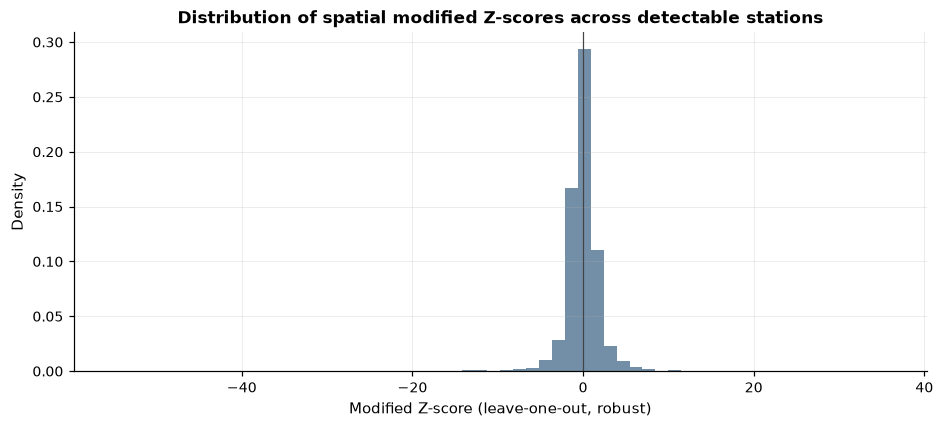

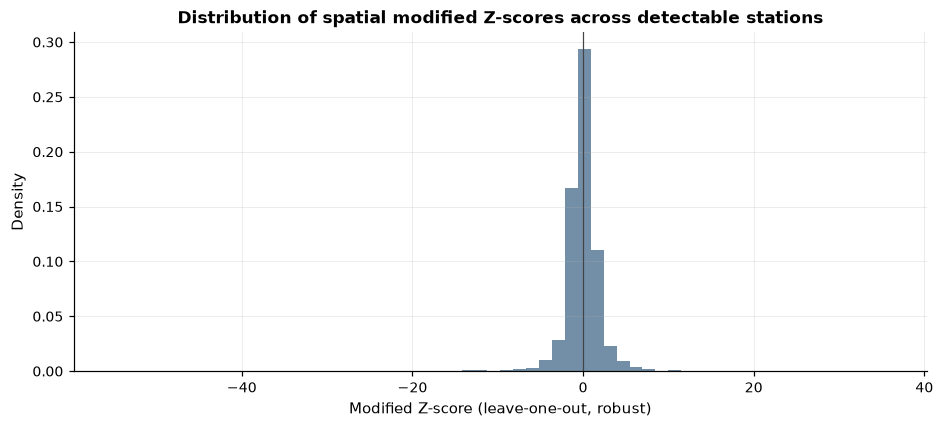

,Property,Value
0,Median,0.000000
1,Interquartile range,1.450000
2,Skewness,-2.640000
3,Share below zero (%),45.200000


In [ ]:
z_valid = zdf.loc[zdf["detectable"], "modified_z"].dropna()

fig, ax = plt.subplots(figsize=(10, 4))
ax.hist(z_valid, bins=60, color="#5B7C99", alpha=0.85, density=True)
ax.axvline(0, color="#444444", linewidth=0.8)
ax.set_xlabel("Modified Z-score (leave-one-out, robust)")
ax.set_ylabel("Density")
ax.set_title("Distribution of spatial modified Z-scores across detectable stations")
plt.savefig(FIGURE_DIR / "03_zscore_distribution.png")
plt.show()

display(table_style(pd.DataFrame([
    ("Median", round(float(z_valid.median()), 2)),
    ("Interquartile range", round(float(z_valid.quantile(0.75) - z_valid.quantile(0.25)), 2)),
    ("Skewness", round(float(sstats.skew(z_valid)), 2)),
    ("Share below zero (%)", round(float((z_valid < 0).mean() * 100), 1)),
], columns=["Property", "Value"]).set_index("Property")))


<u>Interpretation</u>

The score distribution is centred near zero, as expected when most stations are consistent
with their neighbours, and its tails hold the candidate anomalies. Any departure from symmetry
is informative: an excess of negative scores would indicate that under-reporting deviations
outnumber over-reporting ones across the networks, which Section 5 examines by direction. The
shape of the distribution — in particular whether it is heavier-tailed than normal — governs
the thresholding approach assessed in Section 4.

## 4. Suspicion Threshold Derivation



A threshold converts a continuous score into a binary flag, and its value determines how many
stations are called suspicious. Setting it by fiat would make every downstream result hostage
to an unexamined number. The derivation instead follows the pipeline's standard procedure:
take a published anchor, examine the distribution it acts on, test the anchor's sensitivity,
and decide — retaining the anchor if it flags a defensible share of stations, or replacing it
with an empirical value if it does not. The reasoning is recorded either way.

### 4.1 Distributional Assessment



The modified Z-score anchor of 3.5 rests on an approximate normality argument. Whether the
observed scores are in fact normal determines how the anchor should be read: under normality
it corresponds to a specific tail probability, while under heavier tails the same value flags
a larger share of stations. A normality test therefore calibrates expectations before the
sensitivity analysis.

In [19]:
sample = z_valid.sample(min(5000, len(z_valid)), random_state=SEED)
shapiro_stat, shapiro_p = sstats.shapiro(sample)
approx_normal = shapiro_p > 0.05

display(table_style(pd.DataFrame([
    ("Shapiro–Wilk statistic", round(float(shapiro_stat), 4)),
    ("p-value", f"{shapiro_p:.2e}"),
    ("Sample size", f"{len(sample):,}"),
    ("Distribution", "approximately normal" if approx_normal
                     else "not normal (skewed / heavy-tailed)"),
], columns=["Property", "Value"]).set_index("Property"))
)


,Property,Value
0,Shapiro–Wilk statistic,0.650000
1,p-value,8.13e-58
2,Sample size,"2,506"
3,Distribution,not normal (skewed / heavy-tailed)


<u>Interpretation</u>

The scores depart from normality — expected, since even a robust standardisation of
right-skewed concentrations retains some asymmetry, and the anomalies the method is designed
to find populate the tails. The practical consequence is that the 3.5 anchor cannot be read
off a normal table as a fixed tail probability; the share of stations it flags must be
measured directly against the observed distribution. That is the purpose of the sensitivity
analysis.

### 4.2 Sensitivity Analysis



The sensitivity analysis reports the share of stations flagged across a range of candidate
thresholds, and compares the anchor with a purely empirical alternative — the two-sided
97.5th percentile of the absolute scores. A defensible threshold flags a modest share of
stations: too permissive and the method loses discriminating power, too aggressive and it
overwhelms the consensus with false positives. The convention adopted here treats a flagged
share between roughly 0.5% and 10% as reasonable for a baseline screen.

In [20]:
candidate_thresholds = [2.5, 3.0, 3.5, 4.0, 4.5]
sensitivity = {t: round(float((z_valid.abs() > t).mean()), 4) for t in candidate_thresholds}

empirical_threshold = round(float(z_valid.abs().quantile(0.975)), 2)
share_at_anchor = sensitivity[THRESHOLD_ANCHOR]

sensitivity_table = pd.DataFrame({
    "flagged_share_%": {t: round(v * 100, 2) for t, v in sensitivity.items()},
    "stations_flagged": {t: int((z_valid.abs() > t).sum()) for t in candidate_thresholds},
})
sensitivity_table.index.name = "threshold"
sensitivity_table["note"] = ["anchor (I&H 1993)" if t == THRESHOLD_ANCHOR else ""
                             for t in sensitivity_table.index]
display(table_style(sensitivity_table))

display(table_style(pd.DataFrame([
    ("Anchor threshold", THRESHOLD_ANCHOR),
    ("Share flagged at anchor (%)", round(share_at_anchor * 100, 2)),
    ("Empirical threshold (two-sided P97.5)", empirical_threshold),
], columns=["Property", "Value"]).set_index("Property"))
)


,threshold,flagged_share_%,stations_flagged,note
0,2.500000,12.010000,301,
1,3.000000,8.700000,218,
2,3.500000,5.910000,148,anchor (I&H 1993)
3,4.000000,5.230000,131,
4,4.500000,3.790000,95,


,Property,Value
0,Anchor threshold,3.500000
1,Share flagged at anchor (%),5.910000
2,Empirical threshold (two-sided P97.5),5.510000


<u>Interpretation</u>

The flagged share falls steeply as the threshold rises, the signature of a heavy-tailed score
distribution: most stations cluster near zero, and the flagged count is decided in the tail.
The comparison between the anchor and the empirical P97.5 threshold indicates whether the
published convention and the data-driven value agree. When they are close, the anchor is
corroborated by the data; when they diverge sharply, the anchor is flagging a share the
distribution does not support, and the empirical value is preferred. Section 4.3 applies this
rule.

### 4.3 Threshold Decision



The decision rule is explicit and recorded. The published anchor is the default, and it is
replaced by the empirical P97.5 threshold only when two conditions both hold: the anchor
flags a share outside the reasonable band (0.5%–10%), *and* the empirical value itself lies
in a plausible range. The second guard matters because a heavy-tailed score distribution can
push the empirical P97.5 to an implausibly high value; in that case the published convention
is the safer choice, and switching to the empirical value would flag almost nothing. Either
way the outcome and its reason are stored alongside the result.

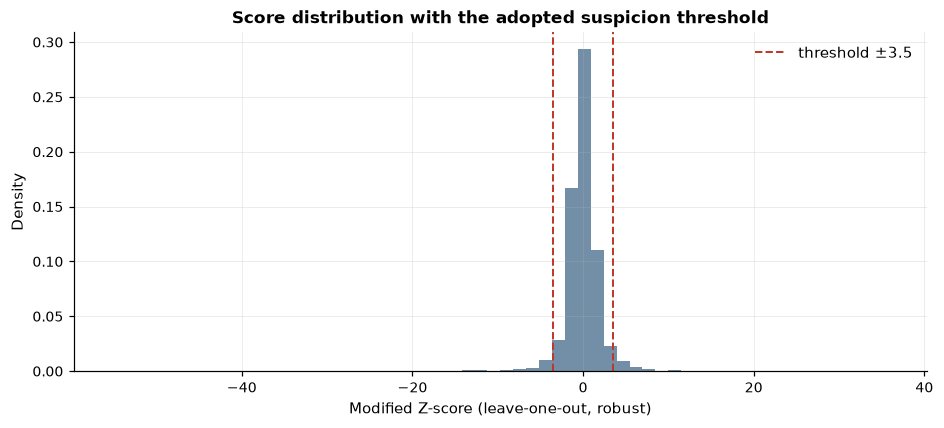

,Field,Value
0,value,3.500000
1,anchor,3.500000
2,anchor_source,"Iglewicz & Hoaglin (1993), modified Z-score convention"
3,empirical_p975,5.510000
4,flagged_share_at_anchor,0.059100
5,basis,anchor_retained
6,rationale,"Anchor 3.5 flags 5.9% of stations, within the reasonable band; the published convention is retained."


In [ ]:
REASONABLE_BAND = (0.005, 0.10)
EMPIRICAL_SANE_MAX = 10.0

anchor_in_band   = REASONABLE_BAND[0] <= share_at_anchor <= REASONABLE_BAND[1]
empirical_is_sane = THRESHOLD_ANCHOR <= empirical_threshold <= EMPIRICAL_SANE_MAX

if anchor_in_band or not empirical_is_sane:
    ZSCORE_THRESHOLD = THRESHOLD_ANCHOR
    basis = "anchor_retained"
    if anchor_in_band:
        rationale = (f"Anchor {THRESHOLD_ANCHOR} flags {share_at_anchor*100:.1f}% of stations, "
                     f"within the reasonable band; the published convention is retained.")
    else:
        rationale = (f"Anchor {THRESHOLD_ANCHOR} flags {share_at_anchor*100:.1f}% (outside the band), "
                     f"but the empirical P97.5={empirical_threshold} is implausibly high "
                     f"(heavy-tailed scores); the published anchor is retained as the safer choice.")
else:
    ZSCORE_THRESHOLD = empirical_threshold
    basis = "empirical_p975"
    rationale = (f"Anchor {THRESHOLD_ANCHOR} flags {share_at_anchor*100:.1f}%, outside the "
                 f"reasonable band, and the empirical P97.5={empirical_threshold} is in a "
                 f"plausible range; the empirical value is adopted.")

threshold_record = {
    "value": ZSCORE_THRESHOLD,
    "anchor": THRESHOLD_ANCHOR,
    "anchor_source": "Iglewicz & Hoaglin (1993), modified Z-score convention",
    "empirical_p975": empirical_threshold,
    "flagged_share_at_anchor": share_at_anchor,
    "basis": basis,
    "rationale": rationale,
}

fig, ax = plt.subplots(figsize=(10, 4))
ax.hist(z_valid, bins=60, color="#5B7C99", alpha=0.85, density=True)
for sign in (+1, -1):
    ax.axvline(sign * ZSCORE_THRESHOLD, color="#C0392B", linestyle="--", linewidth=1.3,
               label=f"threshold ±{ZSCORE_THRESHOLD}" if sign == 1 else None)
ax.set_xlabel("Modified Z-score (leave-one-out, robust)")
ax.set_ylabel("Density")
ax.set_title("Score distribution with the adopted suspicion threshold")
ax.legend()
plt.savefig(FIGURE_DIR / "03_threshold_decision.png")
plt.show()

display(table_style(pd.DataFrame(list(threshold_record.items()),
                     columns=["Field", "Value"]).set_index("Field"))
)


<u>Interpretation</u>

The adopted threshold is recorded with its full provenance: the anchor, its source, the
empirical alternative, and the decision between them. This is the no-orphan-parameters
principle applied to the one free value in the method — the threshold is neither an
unexamined convention nor a number fitted silently to the data, but a documented choice a
reviewer can trace and challenge. It is now applied to flag stations in Section 5.

## 5. Station Flagging and Deviation Direction



The threshold is applied to identify suspicious stations, and the sign of each flagged score
is interpreted as a direction of deviation. Direction carries the substantive meaning: a
station reporting well below its neighbours is a candidate for under-reporting, while one
reporting well above is a candidate for over-reporting or malfunction. The distinction
matters both for interpretation and for the classification scheme in Notebook 09.

### 5.1 Flagging

A station is flagged when it is detectable and its absolute modified Z-score exceeds the
adopted threshold. Undetectable stations are never flagged: absence of a score is not
evidence of consistency.

In [22]:
zdf["flagged"] = zdf["detectable"] & (zdf["abs_z"] > ZSCORE_THRESHOLD)

flag_summary = pd.DataFrame([
    ("Detectable stations", int(zdf["detectable"].sum())),
    ("Flagged as suspicious", int(zdf["flagged"].sum())),
    ("Consistent with neighbours", int((zdf["detectable"] & ~zdf["flagged"]).sum())),
    ("Undetectable", int((~zdf["detectable"]).sum())),
], columns=["Category", "Stations"]).set_index("Category")

display(table_style(flag_summary))


,Category,Stations
0,Detectable stations,2506
1,Flagged as suspicious,148
2,Consistent with neighbours,2358
3,Undetectable,644


<u>Interpretation</u>

The flagged stations are those the spatial baseline considers inconsistent with their local
context. Their number follows directly from the threshold decision in Section 4, and the
explicit separation of "consistent" from "undetectable" preserves the distinction the
consensus in Notebook 06 depends on — a station assessed and cleared is evidence of normality,
while an undetectable station is simply silent.

### 5.2 Direction Classification (SL / SH)



Each flagged station is classified by the sign of its deviation, following the systematically
low / systematically high scheme of Chen et al. (2018). A negative score — a median below the
neighbourhood consensus — is **SL (systematically low)**, the signature of potential
under-reporting. A positive score is **SH (systematically high)**, the signature of potential
over-reporting or instrument drift. The raw absolute score is retained as the suspicion score
passed to the consensus, so that the strength of the deviation, not merely its presence, is
available downstream.

In [23]:
def classify_direction(row):
    if not row["flagged"]:
        return "normal"
    return "SL_under_report" if row["modified_z"] < 0 else "SH_over_report"

zdf["direction"] = zdf.apply(classify_direction, axis=1)
zdf["suspicion_score"] = zdf["abs_z"]

direction_by_country = (zdf[zdf["flagged"]]
                        .groupby(["country", "direction"]).size()
                        .unstack(fill_value=0))

display(table_style(zdf["direction"].value_counts().rename_axis("direction").to_frame("stations")))
display(table_style(direction_by_country))


,direction,stations
0,normal,3002
1,SL_under_report,75
2,SH_over_report,73


direction,country,SH_over_report,SL_under_report
0,China,26,35
1,Germany,7,10
2,India,27,15
3,USA,13,15


<u>Interpretation</u>

The split between systematically low and systematically high stations, and its variation
across networks, is the baseline's substantive finding. A preponderance of SL stations in a
network points toward under-reporting as the dominant anomaly there; a preponderance of SH
toward over-reporting or malfunction. These directional labels feed the classification in
Notebook 09, and the per-country pattern is a result to carry into the report — with the
caveat, established in Notebook 02, that the United States low-value asymmetry can nudge its
stations toward the SL direction for reasons unrelated to reporting behaviour.

## 6. Results and Handoff

This section presents the most suspicious stations and writes the result in the schema the
consensus notebook expects.

### 6.1 Flagged Stations

The stations with the highest suspicion scores are the baseline's strongest candidates. They
are shown with their score and direction, ordered by suspicion.

In [24]:
ranked = (zdf[zdf["flagged"]]
          .sort_values("suspicion_score", ascending=False)
          [["location_id", "country", "n_neighbours", "modified_z", "direction"]]
          .reset_index(drop=True))

display(ranked.head(15).round(2))


,location_id,country,n_neighbours,modified_z,direction
0,site_5272,India,3,-55.11,SL_under_report
1,site_136,India,5,35.72,SH_over_report
2,site_5669,India,7,21.43,SH_over_report
3,site_5959,India,11,20.15,SH_over_report
4,site_5665,India,3,19.64,SH_over_report
5,sta.de_deni070,Germany,3,-17.79,SL_under_report
6,airnow_470654002,USA,6,17.54,SH_over_report
7,site_5661,India,4,16.13,SH_over_report
8,site_5723,India,4,-15.78,SL_under_report
9,site_5131,India,5,-14.30,SL_under_report


<u>Interpretation</u>

These are the candidate anomalies the spatial baseline contributes. They are candidates, not
conclusions: a single method — however principled — can be misled by local conditions the
neighbourhood does not capture, such as a genuine pollution source affecting one station but
not its neighbours. Their standing is settled only in the consensus of Notebook 06, where
agreement across independent methods separates robust signals from method-specific artifacts.
A station flagged here and nowhere else is weaker evidence than one flagged by several
methods.

### 6.2 Output for Consensus



The result is written in the schema shared by every detection notebook, so the consensus can
combine methods uniformly. Every station is written — flagged, consistent, and undetectable
alike — because the consensus needs to know not only which stations each method flagged but
also which it assessed and which it could not reach.

In [25]:
output = (zdf[["location_id", "country", "n_neighbours", "modified_z", "abs_z",
               "suspicion_score", "detectable", "flagged", "direction"]]
          .sort_values("suspicion_score", ascending=False, na_position="last")
          .reset_index(drop=True))

output_path = PROCESSED_DIR / "station_suspicion_zscore.csv"
output.to_csv(output_path, index=False)

display(pd.DataFrame([
    ("Output file", output_path.name),
    ("Stations written", f"{len(output):,}"),
    ("Flagged", f"{int(output['flagged'].sum()):,}"),
    ("Detectable", f"{int(output['detectable'].sum()):,}"),
    ("Schema", "location_id, country, suspicion_score, flagged, direction (+ diagnostics)"),
], columns=["Property", "Value"]).set_index("Property"))


,Value
Property,
Output file,station_suspicion_zscore.csv
Stations written,"3,150"
Flagged,148
Detectable,"2,506"
Schema,"location_id, country, suspicion_score, flagged..."


<u>Interpretation</u>

The result is persisted in the consensus-ready schema. The file records, for every station,
the method's verdict and the diagnostic quantities behind it — score, neighbour count,
detectability — so that Notebook 06 can weight and combine this method's judgement alongside
the others, and so that any individual flag can be traced back to the evidence that produced
it.

## 7. Findings and Limitations

### Findings

**The spatial baseline is operational across all four networks.** <br>Each detectable station was
compared against its leave-one-out neighbourhood using a robust modified Z-score, and a
documented threshold separated suspicious stations from those consistent with their local
context.

**Direction is the substantive output.** <br>Flagged stations are labelled systematically low
(candidate under-reporting) or systematically high (candidate over-reporting), and the
per-country balance of the two is the result carried into the classification of Notebook 09
and the consensus of Notebook 06.

**Detectability bounds the method's reach.** <br>Stations with too few reporting neighbours, or
with a zero-dispersion neighbourhood, cannot be assessed spatially and are marked
undetectable rather than assumed normal — a distinction preserved in the output.

### Limitations

**Single aggregate per station.** <br>The baseline reduces each station to one median over the
whole period, so it detects persistent spatial inconsistency but not transient or
intermittent anomalies — a station that under-reports for one month and reports normally
otherwise may be diluted below the threshold. The time-sliced method in Notebook 08 addresses
this temporal dimension directly.

**Dependence on neighbourhood validity.** <br>The method assumes neighbours share the subject's
atmospheric conditions. Where a genuine local source — a nearby fire, a single industrial
emitter — affects one station but not its neighbours, the station will be flagged despite
reporting correctly. The fire cross-reference in Notebook 07 is the intended check against
this false-positive mode.

**United States low-value asymmetry.** <br>As established in Notebook 02, the United States
network reports a higher share of near-zero concentrations for provider-side reasons. This
can lower a station's median relative to its neighbours and nudge it toward the SL direction
for reasons unrelated to reporting behaviour; United States SL flags should be read with this
in mind.

**Sparse-network sensitivity.** <br>In the sparsest networks the neighbourhood can be as small as
the minimum count, so the reference median and MAD rest on few stations and the resulting
score is comparatively fragile. The neighbour count is retained in the output so that these
cases can be identified downstream.

---

### Output

| File | Contents |
|---|---|
| `station_suspicion_zscore.csv` | Per-station modified Z-score, flag, and deviation direction |

**Next:** `04_isolation_forest.ipynb` — a multivariate detector that considers each station's
full feature profile rather than a single spatial aggregate, contributing an independent
signal to the consensus.

---

### References

Chen, X., et al. (2018). Detecting anomalous data in IoT-based air quality monitoring.
*IEEE Internet of Things Journal*, 5(2).

Cressie, N. (1993). *Statistics for Spatial Data.* Wiley.

Iglewicz, B., & Hoaglin, D. C. (1993). *How to Detect and Handle Outliers.* ASQC Quality
Press. (Modified Z-score; recommended threshold 3.5.)
